In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
import sys
import cv2



In [2]:
import random
import collections
import pickle
import pandas as pd
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics


In [3]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("tristanzhang32/ai-generated-images-vs-real-images")

print("Path to dataset files:", path)

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/buddyreardon/.cache/kagglehub/datasets/tristanzhang32/ai-generated-images-vs-real-images/versions/2


In [5]:
CATEGORIES = ["real", "fake"]
IMG_SIZE = 80

def find_category_folder(PATH, category):
    for root, dirs, files in os.walk(PATH):
        if os.path.basename(root).lower() == category.lower():
            return root
    return None

In [6]:
def getImages(PATH, IMG_SIZE):
    imgList = []

    for category in CATEGORIES:
        target_num = CATEGORIES.index(category)
        folder_path = find_category_folder(PATH, category)

        print("Reading from:", folder_path)

        if folder_path is None:
            print("Missing:", category)
            continue

        for img in os.listdir(folder_path):
            try:
                filename = os.path.join(folder_path, img)

                img_array = cv2.imread(filename)

                if img_array is None:
                    continue

                new_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))
                imgList.append([new_array, target_num])

            except:
                pass

    return imgList


In [7]:
totalData = getImages(path, IMG_SIZE)

print("Total images loaded:", len(totalData))


Reading from: /Users/buddyreardon/.cache/kagglehub/datasets/tristanzhang32/ai-generated-images-vs-real-images/versions/2/test/real


Premature end of JPEG file
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 9 extraneous bytes before marker 0xda
Premature end of JPEG file
libpng error: Read Error


Reading from: /Users/buddyreardon/.cache/kagglehub/datasets/tristanzhang32/ai-generated-images-vs-real-images/versions/2/test/fake


Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 29706 extraneous bytes before marker 0xd9
Corrupt JPEG data: 253617 extraneous bytes before marker 0xd9
Corrupt JPEG data: 107 extraneous bytes before marker 0xd9
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 4792 extraneous bytes before marker 0xd9
libpng warning: iCCP: known incorrect sRGB profile
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: premature end of data segment
Corrupt JPEG data: 17745 extraneous bytes before marker 0xd9
Corrupt JPEG data: 7735 extraneous bytes before marker 0xd9
Corrupt JPEG data: 2811 extraneous bytes before marker 0xd9
Corrupt JPEG data: 27 extraneous bytes before marker 0xd9
Corrupt JPEG data: 5464 ext

Total images loaded: 11999


In [8]:
random.shuffle(totalData)

Total Images 11999
Category real = 5999
Category fake = 6000


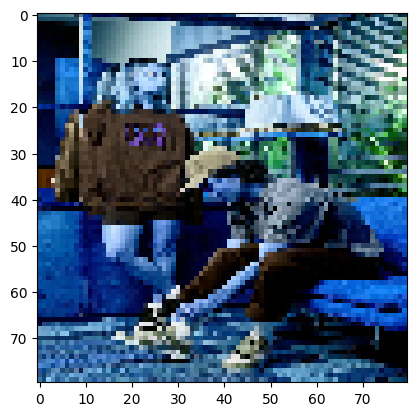

This is  real


In [9]:
'''
picking random values this will paste the image and its type

this can be a way to look at newly tested image size

'''
who = 0

print( "Total Images",len( totalData ))
countList = [i[1] for i in totalData ]
ctr = collections.Counter( countList )
for i in CATEGORIES :
    print("Category",i,"=",ctr[ CATEGORIES.index(i)] )

random.shuffle( totalData )
theRecord = totalData[who]
theValue = theRecord[1]
theImg = theRecord[0]
plt.imshow( theImg, cmap="gray" )
plt.show()

print("This is ",CATEGORIES[ theValue ] )

In [10]:
X = []
Y = []

for [features,label] in totalData :         #[image, zero or 1 for real or fake]
    X.append( features )
    Y.append( label )

X = np.array(X).reshape(-1, IMG_SIZE, IMG_SIZE, 3) #1 would be 3 if you want color,  -1 will just show how many rows
Y = np.array(Y)

print(X.shape)
print(Y.shape)

(11999, 80, 80, 3)
(11999,)


In [11]:
X=X/255 #0-1 for images

## Neural Network

In [12]:
from sklearn.model_selection import train_test_split
import sklearn.metrics as metrics
from sklearn.metrics import classification_report, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns


import tensorflow as tf
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv2D, MaxPooling2D

In [13]:
'''
train test
'''

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, train_size=0.8, test_size=0.2, random_state=1)

In [14]:

"""
MODEL ACCURACY METRICS
"""

def get_TF_ProbAccuracyScores( NAME, MODEL, X, Y ) :
    probs = MODEL.predict( X )
    pred_list = []
    for p in probs :
        pred_list.append( np.argmax( p ) )
    pred = np.array( pred_list )
    acc_score = metrics.accuracy_score(Y, pred)
    p1 = probs[:,1]
    fpr, tpr, threshold = metrics.roc_curve( Y, p1)
    auc = metrics.auc(fpr,tpr)
    return [NAME, acc_score, fpr, tpr, auc]


def print_ROC_Curve( TITLE, LIST ) :
    pass
    fig = plt.figure(figsize=(6,4))
    plt.title( TITLE )
    for theResults in LIST :
        NAME = theResults[0]
        fpr = theResults[2]
        tpr = theResults[3]
        auc = theResults[4]
        theLabel = "AUC " + NAME + ' %0.2f' % auc
        plt.plot(fpr, tpr, label = theLabel )
    plt.legend(loc = 'lower right')
    plt.plot([0, 1], [0, 1],'r--')
    plt.xlim([0, 1])
    plt.ylim([0, 1])
    plt.ylabel('True Positive Rate')
    plt.xlabel('False Positive Rate')
    plt.show()

def print_Accuracy( TITLE, LIST ) :
    print( TITLE )
    print( "======" )
    for theResults in LIST :
        NAME = theResults[0]
        ACC = theResults[1]
        print( NAME, " = ", ACC )
    print( "------\n\n" )

    
def confusion_Matrix( NAME, MODEL, X, Y ) :
    probs = MODEL.predict( X )
    probs = list( probs[0] )
    print( probs )
    maxValue = max( probs )
    print(maxValue)

In [23]:
Z=X[0]
B_theShapeSize = Z.shape
B_theActivation = tf.keras.activations.relu
B_theLossMetric = tf.keras.losses.SparseCategoricalCrossentropy()
B_theOptimizer = tf.keras.optimizers.Adam()

# Fill in the values that will give the best results
B_theEpochs = 9
B_theUnits = 200

In [24]:
B_LAYER_CONV2D_01 = tf.keras.layers.Conv2D( B_theUnits, (3,3), activation=B_theActivation, input_shape=B_theShapeSize  )
B_LAYER_POOL_01 = tf.keras.layers.MaxPooling2D( pool_size=(2,2) ) #pool will cut in half

B_LAYER_CONV2D_02 = tf.keras.layers.Conv2D( 2*B_theUnits, (3,3), activation=B_theActivation, input_shape=B_theShapeSize  ) #double filters
B_LAYER_POOL_02 = tf.keras.layers.MaxPooling2D( pool_size=(2,2) ) #cut pool in half again 

B_LAYER_CONV2D_03 = tf.keras.layers.Conv2D( 4*B_theUnits, (3,3), activation=B_theActivation, input_shape=B_theShapeSize  )
B_LAYER_POOL_03 = tf.keras.layers.MaxPooling2D( pool_size=(2,2) )

B_LAYER_CONV2D_04 = tf.keras.layers.Conv2D( 4*B_theUnits, (3,3), activation=B_theActivation, input_shape=B_theShapeSize  )
B_LAYER_POOL_04 = tf.keras.layers.MaxPooling2D( pool_size=(2,2) )


B_LAYER_FLATTEN = tf.keras.layers.Flatten()

B_LAYER_DENSE_01 = tf.keras.layers.Dense( units=8*B_theUnits, activation=B_theActivation )
B_LAYER_DROP = tf.keras.layers.Dropout( 0.2 )
B_LAYER_OUT = tf.keras.layers.Dense(2, activation='softmax' )



model_B = tf.keras.models.Sequential()

model_B.add( B_LAYER_CONV2D_01 )
model_B.add( B_LAYER_POOL_01 )
model_B.add( B_LAYER_CONV2D_02 )
model_B.add( B_LAYER_POOL_02 )
model_B.add( B_LAYER_CONV2D_03 )
model_B.add( B_LAYER_POOL_03 )
model_B.add( B_LAYER_CONV2D_04 )
model_B.add( B_LAYER_POOL_04 )
model_B.add( B_LAYER_FLATTEN )
model_B.add( B_LAYER_DENSE_01 )
model_B.add( B_LAYER_DROP )
model_B.add( B_LAYER_OUT )

model_B.compile( optimizer = B_theOptimizer, loss=B_theLossMetric, metrics=['accuracy'] )
model_B.fit( X_train, Y_train, epochs=B_theEpochs )

/Library/Frameworks/Python.framework/Versions/3.13/lib/python3.13/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/9
300/300 ━━━━━━━━━━━━━━━━━━━━ 250s 832ms/step - accuracy: 0.5904 - loss: 0.6891
Epoch 2/9
300/300 ━━━━━━━━━━━━━━━━━━━━ 245s 815ms/step - accuracy: 0.6767 - loss: 0.5987
Epoch 3/9
300/300 ━━━━━━━━━━━━━━━━━━━━ 245s 817ms/step - accuracy: 0.7097 - loss: 0.5634
Epoch 4/9
300/300 ━━━━━━━━━━━━━━━━━━━━ 247s 823ms/step - accuracy: 0.7342 - loss: 0.5353
Epoch 5/9
300/300 ━━━━━━━━━━━━━━━━━━━━ 248s 828ms/step - accuracy: 0.7486 - loss: 0.5138
Epoch 6/9
300/300 ━━━━━━━━━━━━━━━━━━━━ 248s 828ms/step - accuracy: 0.7561 - loss: 0.4982
Epoch 7/9
300/300 ━━━━━━━━━━━━━━━━━━━━ 243s 810ms/step - accuracy: 0.7723 - loss: 0.4783
Epoch 8/9
300/300 ━━━━━━━━━━━━━━━━━━━━ 252s 839ms/step - accuracy: 0.7846 - loss: 0.4596
Epoch 9/9
300/300 ━━━━━━━━━━━━━━━━━━━━ 242s 805ms/step - accuracy: 0.8082 - loss: 0.4192


300/300 ━━━━━━━━━━━━━━━━━━━━ 70s 232ms/step
75/75 ━━━━━━━━━━━━━━━━━━━━ 17s 233ms/step


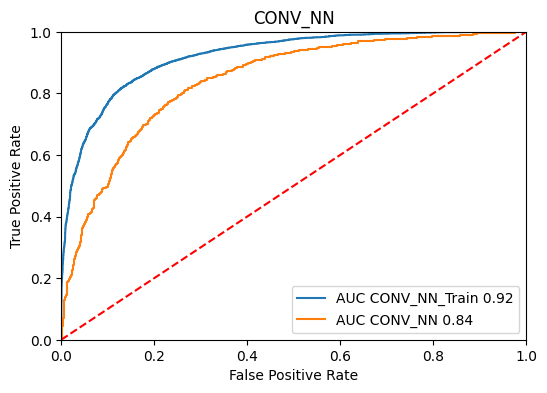

CONV_NN CLASSIFICATION ACCURACY
CONV_NN_Train  =  0.8432128346702782
CONV_NN  =  0.7629166666666667
------




In [25]:
WHO = "CONV_NN"

TRAIN_RES = get_TF_ProbAccuracyScores( WHO + "_Train", model_B, X_train, Y_train )
TEST_RES = get_TF_ProbAccuracyScores( WHO, model_B, X_test, Y_test )

print_ROC_Curve( WHO, [ TRAIN_RES, TEST_RES ] ) 
print_Accuracy( WHO + " CLASSIFICATION ACCURACY", [ TRAIN_RES, TEST_RES ] )

## Test With My Images 

In [26]:
IMG_SIZE = 80

PATH = '/Users/buddyreardon/Desktop/tensor_flow_test'



IMGFILE = 'cow.jpeg'

In [27]:
FILENAME = os.path.join(PATH, IMGFILE)
print(FILENAME)

IMG_RAW = cv2.imread(FILENAME)   # color image
IMG = cv2.resize(IMG_RAW, (IMG_SIZE, IMG_SIZE))

X_RAW = np.array(IMG).reshape(-1, IMG_SIZE, IMG_SIZE, 3)
X_RAW = X_RAW / 255.0

Y = model_B.predict(X_RAW)
print(Y)

/Users/buddyreardon/Desktop/tensor_flow_test/cow.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step
[[0.47640246 0.5235976 ]]


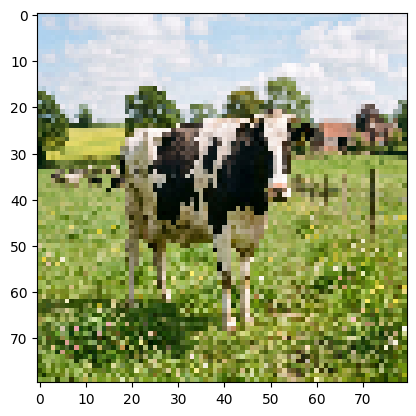

In [28]:
plt.imshow(cv2.cvtColor(IMG, cv2.COLOR_BGR2RGB))
plt.show()

In [29]:
# Normalize the Data

print( X_RAW.shape )
print( X_RAW.shape[1:] )

(1, 80, 80, 3)
(80, 80, 3)


In [30]:
CATEGORIES = ["real","fake"]
Y = list( Y[0] )
print( Y )

maxValue = max( Y )
theIndex = Y.index( maxValue )

print("This is  .....", CATEGORIES[ theIndex ])

[np.float32(0.47640246), np.float32(0.5235976)]
This is  ..... fake


## Save model

In [31]:
 model_B.save("ai_image_detector.keras")

In [32]:
import sys
print(sys.executable)

/Library/Frameworks/Python.framework/Versions/3.13/bin/python3.13
